<a href="https://colab.research.google.com/github/jaredlan1/getting_started_with_ML/blob/main/HW8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [12]:
import os
if os.path.exists('/content/drive'):
    print('Google Drive is mounted.')
else:
    print('Google Drive is NOT mounted.')

Google Drive is mounted.


In [13]:
lfdata = np.load('/content/drive/MyDrive/Physics Informed ML/HW/HW8/sr_lfdata.npy')
hfdata = np.load("/content/drive/MyDrive/Physics Informed ML/HW/HW8/sr_hfdata.npy")

# low resolution
lfx = lfdata[0,:,:]
lfy = lfdata[1,:,:]
lfu = lfdata[4,:,:]
lfv = lfdata[5,:,:]

# high resolution grid
Jinv   = hfdata[0,:,:]
dxdxi  = hfdata[1,:,:]
dxdeta = hfdata[2,:,:]
dydxi  = hfdata[3,:,:]
dydeta = hfdata[4,:,:]
hfx    = hfdata[5,:,:]
hfy    = hfdata[6,:,:]

# true high resolution velocities (for MSE evaluation)
hfu = hfdata[7,:,:]
hfv = hfdata[8,:,:]

ny, nx = hfx.shape
h = 0.01

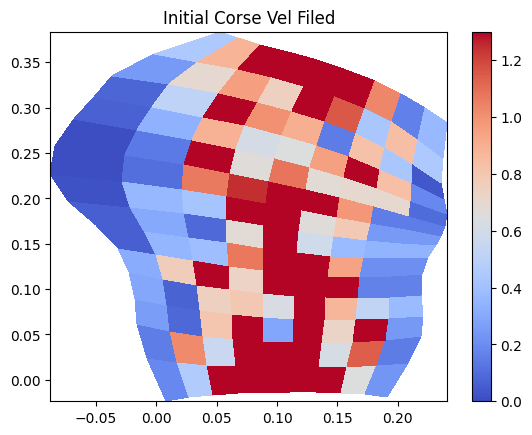

In [14]:
plt.figure()
plt.pcolormesh(lfx, lfy, np.sqrt(lfu**2 + lfv**2),
               cmap=cm.coolwarm, vmin=0, vmax=1.3)
plt.colorbar()
plt.title("Initial Corse Vel Filed")
plt.show()

In [15]:
inp = torch.tensor(
    np.stack([lfu, lfv], axis=0),
    dtype=torch.float32).unsqueeze(0).to(device)

true_uv = torch.tensor(
    np.stack([hfu, hfv], axis=0),
    dtype=torch.float32
).unsqueeze(0).to(device)

Jinv_t   = torch.tensor(Jinv).unsqueeze(0).unsqueeze(0).float().to(device)
dxdxi_t  = torch.tensor(dxdxi).unsqueeze(0).unsqueeze(0).float().to(device)
dxdeta_t = torch.tensor(dxdeta).unsqueeze(0).unsqueeze(0).float().to(device)
dydxi_t  = torch.tensor(dydxi).unsqueeze(0).unsqueeze(0).float().to(device)
dydeta_t = torch.tensor(dydeta).unsqueeze(0).unsqueeze(0).float().to(device)


In [16]:
def ddxi(f, h):
    dfdx_centarl =(f[:,:,:,0:-4] - 8*f[:,:,:,1:-3] + 8*f[:,:,:,3:-1] - f[:,:,:,4:])/(12*h)
    dfdx_left =(-11*f[:,:,:,0:2] + 18*f[:,:,:,1:3] -9*f[:,:,:,2:4] + 2*f[:,:,:,3:5])/(6*h)
    dfdx_right=(-2*f[:,:,:,-5:-3] + 9*f[:,:,:,-4:-2] -18*f[:,:,:,-3:-1] + 11*f[:,:,:,-2:])/(6*h)
    return torch.cat((dfdx_left, dfdx_centarl, dfdx_right), dim=3)

def ddeta(f, h):
    dfdy_central= (f[:,:,0:-4,:] - 8*f[:,:,1:-3,:] + 8*f[:,:,3:-1,:] - f[:,:,4:,:])/(12*h)
    dfdy_bot= (-11*f[:,:,0:2,:] + 18*f[:,:,1:3,:] -9*f[:,:,2:4,:] + 2*f[:,:,3:5,:])/(6*h)
    dfdy_top = (-2*f[:,:,-5:-3,:] + 9*f[:,:,-4:-2,:] -18*f[:,:,-3:-1,:] + 11*f[:,:,-2:,:])/(6*h)
    return torch.cat((dfdy_bot, dfdy_central, dfdy_top), dim=2)

In [17]:
def grad_xy(f):

    f_xi = ddxi(f,h)
    f_eta = ddeta(f,h)

    dfdx = Jinv_t*(f_xi*dydeta_t - f_eta*dydxi_t)
    dfdy = Jinv_t*(f_eta*dxdxi_t - f_xi*dxdeta_t)

    return dfdx, dfdy


def laplace_xy(f):

    fx, fy= grad_xy(f)
    fxx,_ =grad_xy(fx)
    _,fyy=grad_xy(fy)

    return fxx + fyy

In [18]:
class SRCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.up =nn.Upsample(size=(75,47), mode='bicubic', align_corners=True)

        self.net=nn.Sequential(
            nn.Conv2d(2,16,5,padding=2),
            nn.ReLU(),
            nn.Conv2d(16,32,5,padding=2),
            nn.ReLU(),
            nn.Conv2d(32,16,5,padding=2),
            nn.ReLU(),
            nn.Conv2d(16,3,5,padding=2)
        )

        self.pad = nn.ConstantPad2d(1,0)

    def apply_bc(self,x):

        x = self.pad(x)

        u= x[:,0:1,:,:]
        v = x[:,1:2,:,:]
        p =x[:,2:3,:,:]

        # bottom inflow
        u[:,:,0,:]= 0
        v[:,:,0,:] =1
        p[:,:,0,:] =  p[:,:,1,:]

        # outlet
        u[:,:,-1,:]= u[:,:,-2,:]
        v[:,:,-1,:]= v[:,:,-2,:]
        p[:,:,-1,:]= 0

        # walls
        u[:,:,:,0]= 0
        u[:,:,:,-1]= 0
        v[:,:,:,0] =0
        v[:,:,:,-1]=0

        p[:,:,:,0]=p[:,:,:,1]
        p[:,:,:,-1] =p[:,:,:,-2]

        return torch.cat((u,v,p),dim=1)

    def forward(self,x):

        x= self.up(x)
        x =self.net(x)
        x =self.apply_bc(x)

        return x

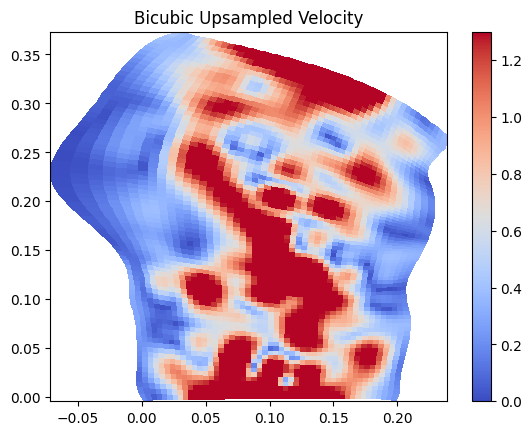

In [19]:
bicubic = F.interpolate(inp, size=(77,49), mode='bicubic', align_corners=True)

bic_u = bicubic[0,0].cpu().numpy()
bic_v = bicubic[0,1].cpu().numpy()

plt.figure()
plt.pcolormesh(hfx, hfy, np.sqrt(bic_u**2 + bic_v**2),
               cmap=cm.coolwarm, vmin=0, vmax=1.3)
plt.colorbar()
plt.title("Bicubic Upsampled Velocity")
plt.show()

In [20]:
model = SRCNN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 3000

loss_history_array = []
mse_history_arr = []

for ep in range(epochs):

    optimizer.zero_grad()

    out= model(inp)

    u= out[:,0:1,:,:]
    v =out[:,1:2,:,:]
    p= out[:,2:3,:,:]

    dudx,dudy= grad_xy(u)
    dvdx,dvdy=grad_xy(v)
    dpdx,dpdy= grad_xy(p)

    lap_u= laplace_xy(u)
    lap_v= laplace_xy(v)

    r1= dudx + dvdy

    r2= u*dudx+ v*dudy+ dpdx - 0.01*lap_u
    r3= u*dvdx +v*dvdy +dpdy - 0.01*lap_v

    loss = torch.mean(r1**2) +torch.mean(r2**2) +torch.mean(r3**2)

    loss.backward()
    optimizer.step()

    loss_history_array.append(loss.item())

    mse= torch.mean((u-true_uv[:,0:1,:,:])**2 + (v-true_uv[:,1:2,:,:])**2)
    mse_history_arr.append(mse.item())

    if ep%200==0:
        print(ep, loss.item())

0 50670.5625
200 4371.89990234375
400 3681.81982421875
600 3173.737548828125
800 2989.97021484375
1000 2931.775390625
1200 2908.07763671875
1400 2902.89404296875
1600 2883.40380859375
1800 2875.470703125
2000 2876.2919921875
2200 2862.499755859375
2400 2864.69287109375
2600 2855.73974609375
2800 2852.3486328125


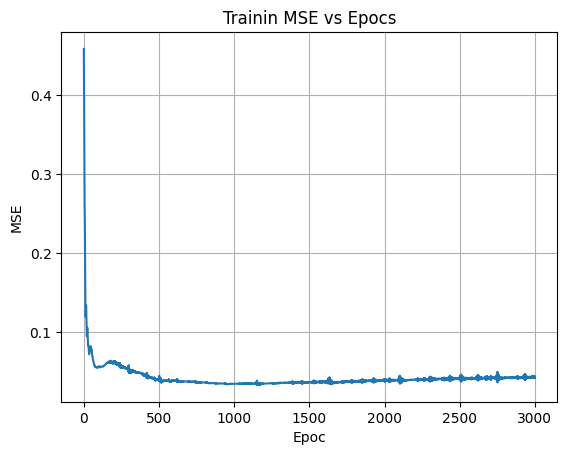

In [22]:
plt.figure()
plt.plot(mse_history_arr)
plt.xlabel("Epoc")
plt.ylabel("MSE")
plt.title("Trainin MSE vs Epocs")
plt.grid()
plt.show()

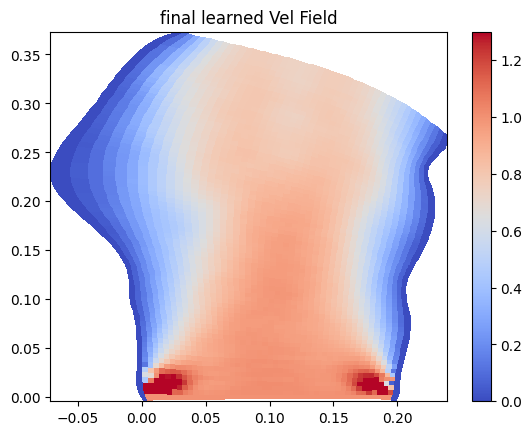

In [24]:
model.eval()

with torch.no_grad():
    out =model(inp)

u_pred= out[0,0].cpu().numpy()
v_pred = out[0,1].cpu().numpy()

plt.figure()
plt.pcolormesh(hfx, hfy, np.sqrt(u_pred**2 + v_pred**2),cmap=cm.coolwarm, vmin=0, vmax=1.3)
plt.colorbar()
plt.title("final learned Vel Field")
plt.show()